Trying out Shap : First Iteration Model


In [2]:
import xgboost 
import pickle
import pandas as pd
# import matplotlib
import matplotlib.pyplot as plt

# Load the model
with open('xgb_model.pkl', 'rb') as f:
    model = pickle.load(f)
    
# with open("gridxgb_model.pkl", "wb") as f:
#     model2 = pickle.load(f)
    
# with open("rf_model.pkl", "wb") as f:
#     model2 = pickle.load(f)

In [3]:
import shap

# Create explainer for tree-based models
explainer = shap.TreeExplainer(model)
# explainer_rf = shap.TreeExplainer(model2)

c:\Users\kavis\OneDrive\Desktop\Study Resources\Year 3\Diss\Code\Dissertation_ExplainableAI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Calculate SHAP values for test set
test_df = pd.read_csv('test.csv')
X_test = test_df.drop(columns=["TenYearCHD", "stratify"])
shap_values = explainer.shap_values(X_test)
# shap_values_rf = explainer_rf.shap_values(X_test)

# Get expected value (baseline)
expected_value = explainer.expected_value
# expected_value_rf = explainer_rf.expected_value 

male                 1.00
age                 51.00
currentSmoker        0.00
cigsPerDay           0.00
BPMeds               0.00
prevalentStroke      0.00
prevalentHyp         1.00
diabetes             0.00
totChol            227.00
sysBP              158.00
diaBP              105.00
BMI                 27.22
heartRate           60.00
glucose             96.00
Name: 70, dtype: float64


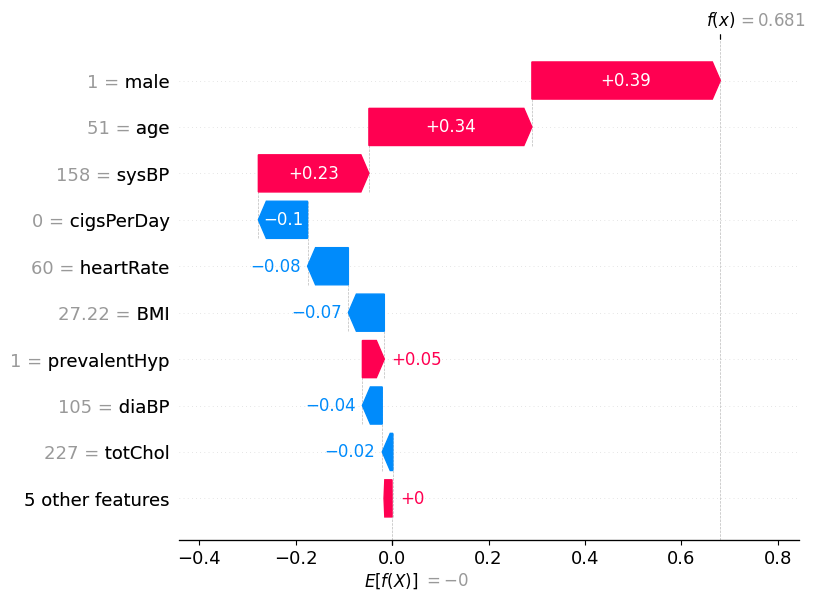

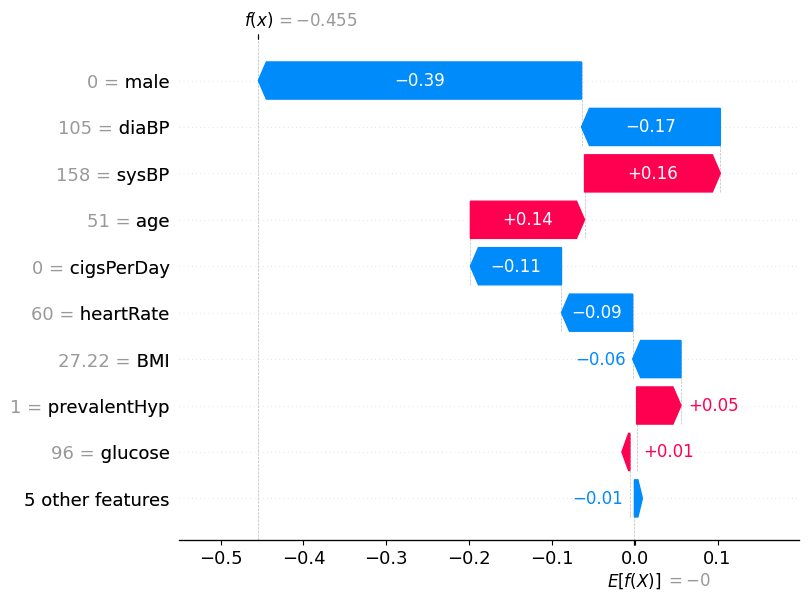

In [5]:
# Summary plot (global feature importance)
# shap.summary_plot(shap_values, X_test)

# # Beeswarm plot (more detailed)
# shap.summary_plot(shap_values, X_test, plot_type="dot")

# Waterfall plot for single patient (first test patient)
male_patient = X_test.iloc[70]
female_patient = male_patient.copy()

female_patient['male'] = 0

created_pair = pd.DataFrame([male_patient, female_patient])
print(male_patient)
shap_values_pair = explainer.shap_values(created_pair)



shap.waterfall_plot(shap.Explanation(
    values=shap_values_pair[0],
    base_values=expected_value,
    data=created_pair.iloc[0],
    feature_names=X_test.columns.tolist()
))

shap.waterfall_plot(shap.Explanation(
    values=shap_values_pair[1],
    base_values=expected_value,
    data=created_pair.iloc[1],
    feature_names=X_test.columns.tolist()
))

# shap.waterfall_plot(shap.Explanation(
#     values=shap_values_rf[28],
#     base_values=expected_value_rf,
#     data=X_test.iloc[28],
#     feature_names=X_test.columns.tolist()
# ))

# shap.waterfall_plot(shap.Explanation(
#     values=shap_values[100],
#     base_values=expected_value,
#     data=X_test.iloc[100],
#     feature_names=X_test.columns.tolist()
# ))

In [6]:
#  SHAP on the cardio_dataset trained baseline model
with open("models/baseline_models/cardio_xgb_baseline_model.pkl", 'rb') as f:
    model_baseline = pickle.load(f)

explainer_baseline = shap.TreeExplainer(model_baseline)

In [7]:
# Calculate SHAP values for test set
test_df_baseline = pd.read_csv('data/test_train_val_sets/cardio_baseline_test.csv')
X_test_baseline = test_df_baseline.drop(columns=["cardio", "stratify"])
shap_values_baseline = explainer_baseline.shap_values(X_test_baseline)
# shap_values_rf = explainer_rf.shap_values(X_test)

# Get expected value (baseline)
expected_value = explainer_baseline.expected_value

# expected_value_rf = explainer_rf.expected_value 

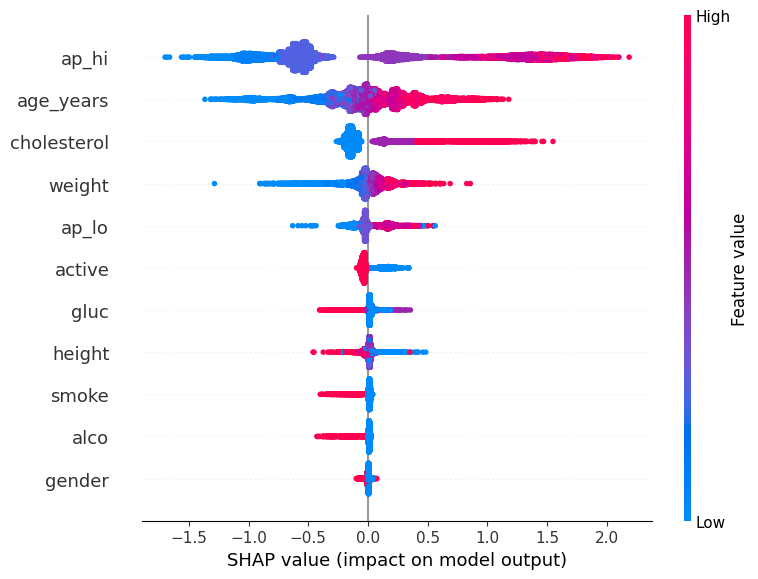

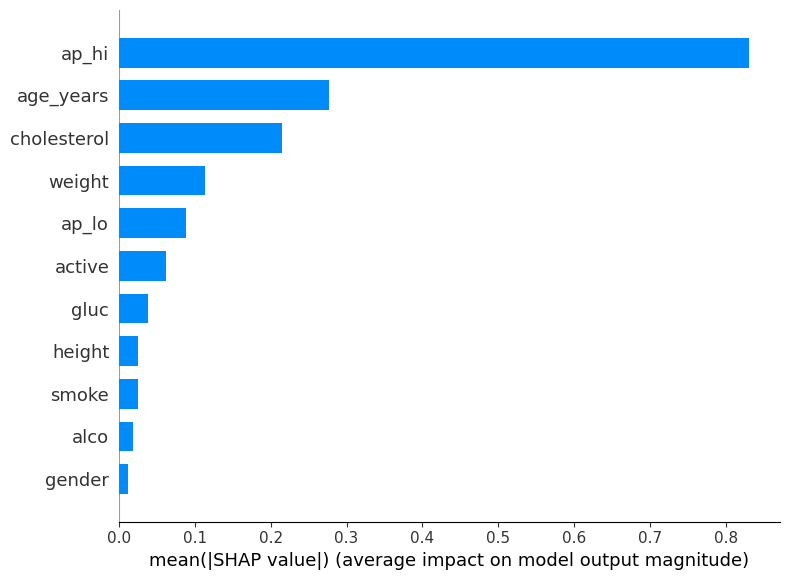

In [8]:
shap.summary_plot(shap_values_baseline, X_test_baseline, plot_type="dot")
shap.summary_plot(shap_values_baseline, X_test_baseline, plot_type="bar")



# Sex-Stratified SHAP now

In [9]:
X_test_female = X_test_baseline[X_test_baseline['gender'] == 0]
X_test_male   = X_test_baseline[X_test_baseline['gender'] == 1]

shap_values_female = explainer_baseline.shap_values(X_test_female)
shap_values_male   = explainer_baseline.shap_values(X_test_male)


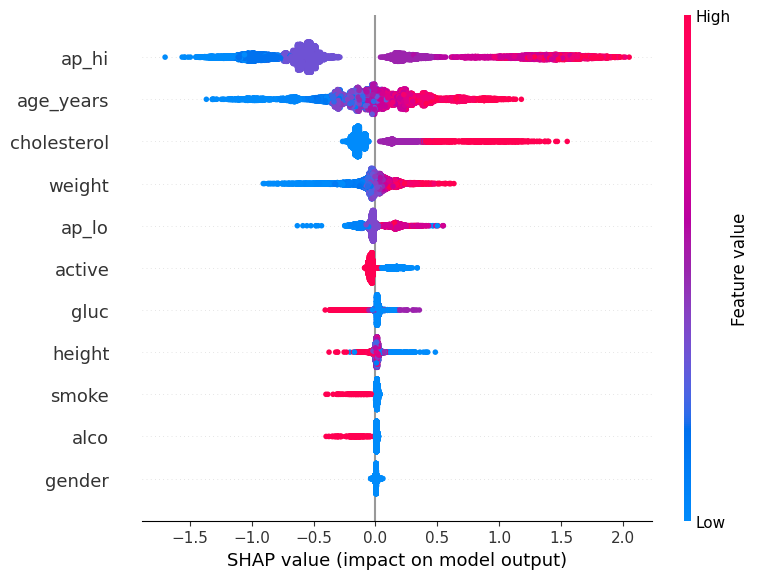

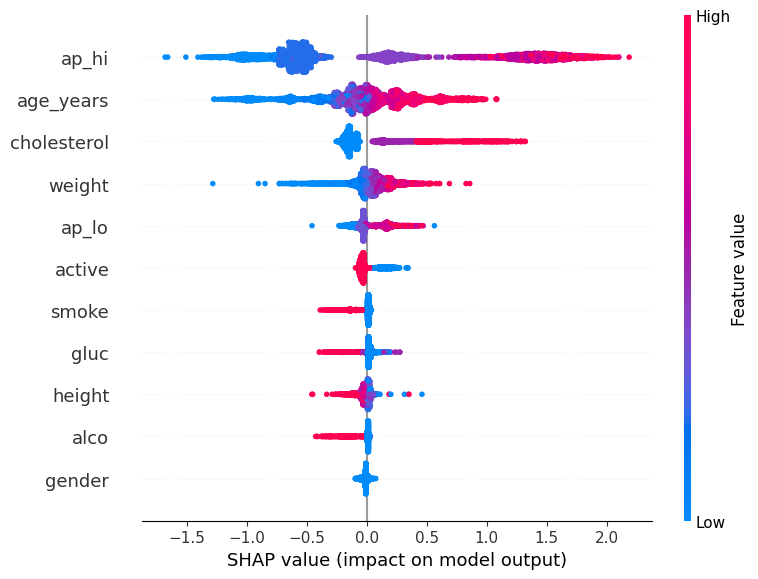

In [10]:
shap.summary_plot(shap_values_female, X_test_female, plot_type="dot")
shap.summary_plot(shap_values_male, X_test_male, plot_type="dot")

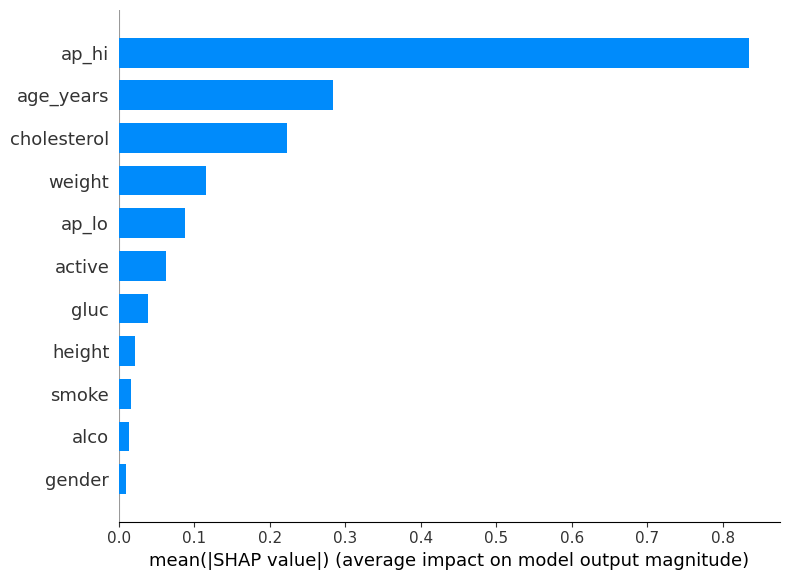

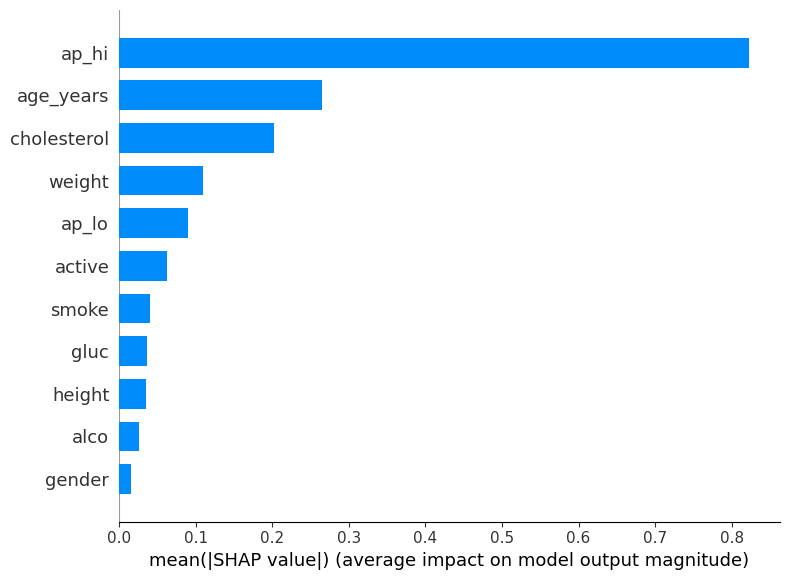

In [11]:
shap.summary_plot(shap_values_female, X_test_female, plot_type="bar")
shap.summary_plot(shap_values_male, X_test_male, plot_type="bar")

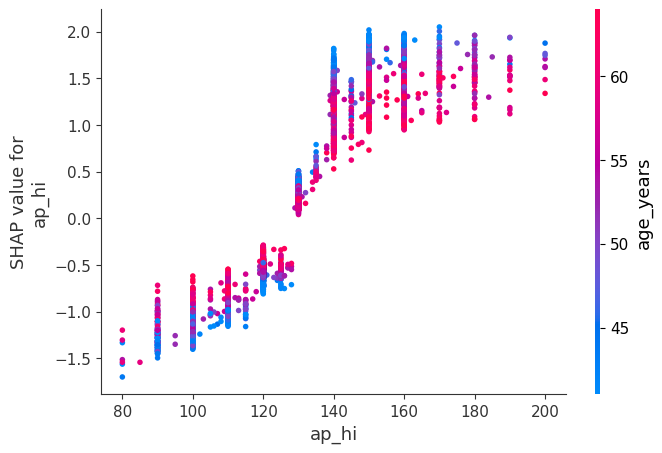

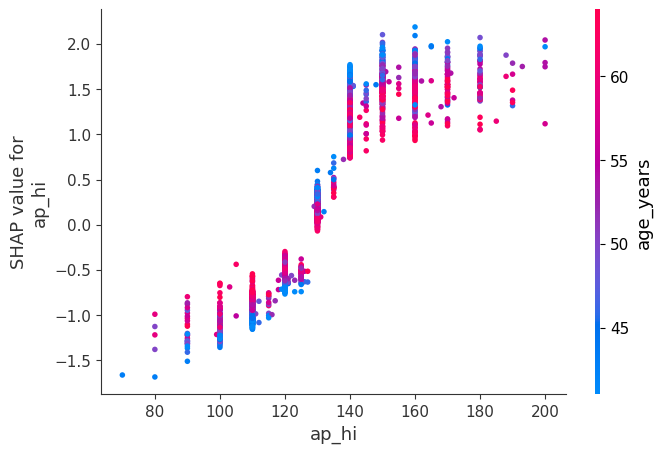

In [12]:
shap.dependence_plot("ap_hi", shap_values_female, X_test_female)
shap.dependence_plot("ap_hi", shap_values_male, X_test_male)

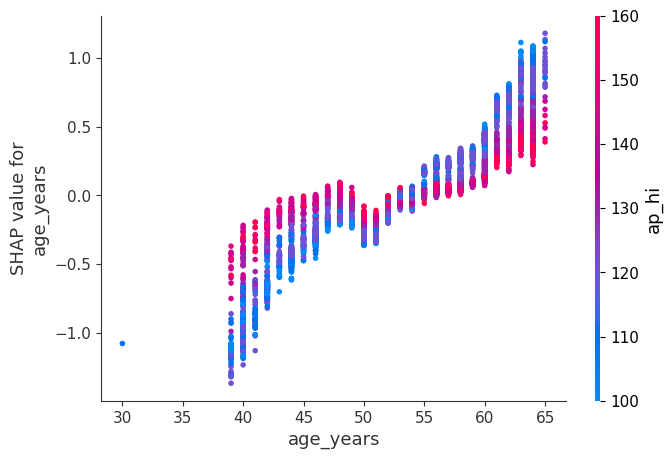

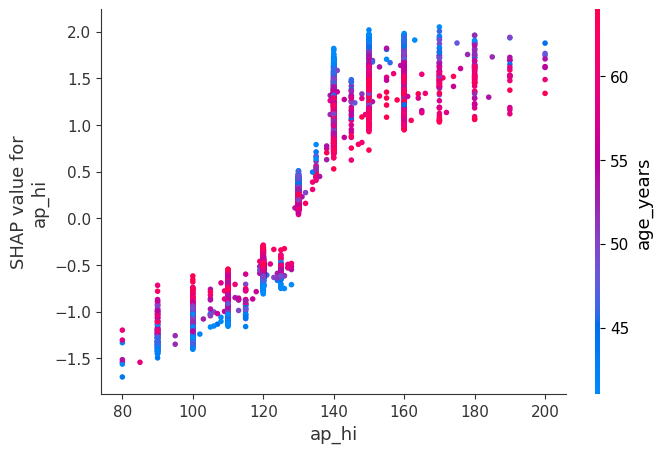

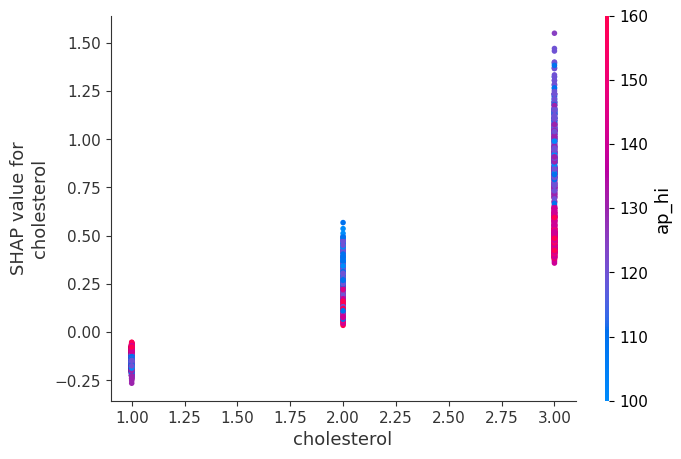

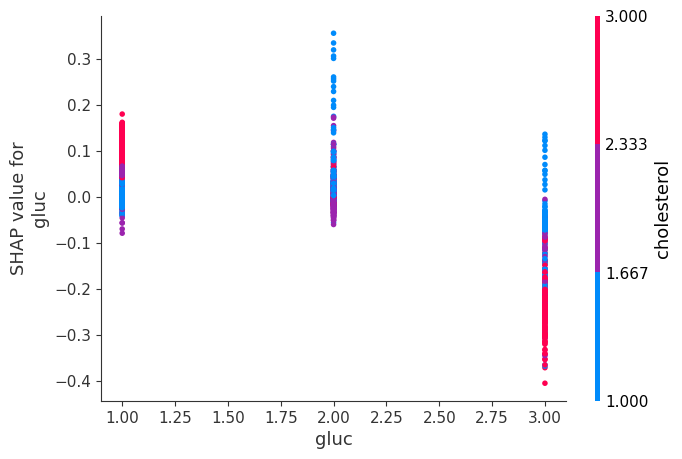

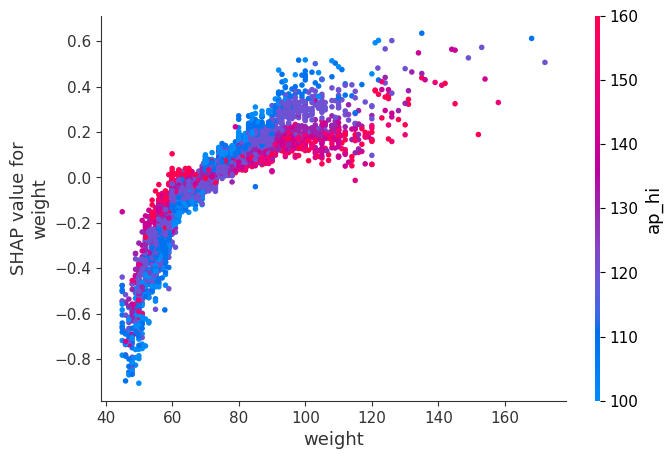

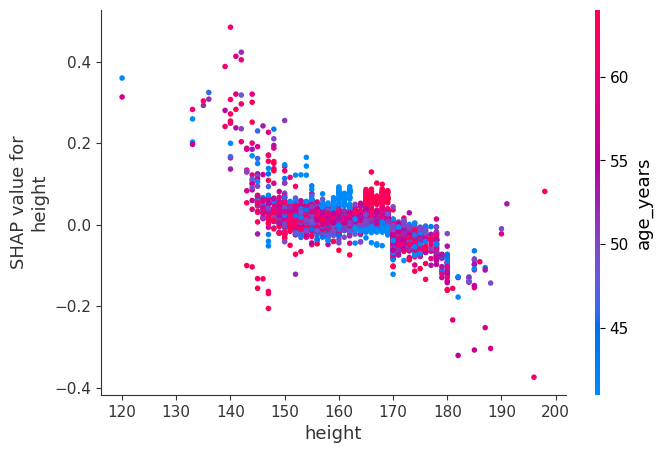

In [ ]:
features = ["age_years", "ap_hi", "cholesterol", "gluc", "weight", "height"]

for f in features:
    shap.dependence_plot(f, shap_values_female, X_test_female)